# Composition maps

### Overview

Maps composition

**Input:** `checkpoints/event_sequences.jsonl`
**Output:** `outputs_event_chains/composition_maps/`

## 1. Setup

In [17]:
# Cell 1: Imports

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams["figure.dpi"] = 110

In [ ]:
# Cell 2: Parameters

CHECKPOINTS = Path("checkpoints")
OUT_DIR     = Path("outputs_event_chains/composition_maps")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEQ_PATH    = CHECKPOINTS / "event_sequences.jsonl"
NESTED_PATH = Path("data/label_to_nested_mapping_reference.csv")
CLEANED     = Path("data/stylecom_cleaned.csv")

nested_df       = pd.read_csv(NESTED_PATH)
LABEL_TO_MR     = dict(zip(nested_df["Label"], nested_df["MR_nested"]))
LABEL_TO_AGENCY = dict(zip(nested_df["Label"], nested_df["Agency_nested"]))

ALPHABETS = [
    ("Cluster_30", None),
    ("MR_4",       LABEL_TO_MR),
    ("Agency_6",   LABEL_TO_AGENCY),
]

ERA_YEARS = 3

In [ ]:
# Cell 3: Load once: build a count matrix per alphabet

with open(SEQ_PATH) as f:
    sequences = [json.loads(line) for line in f]

_MISSING = {"", "nan", "none"}
sequences = [s for s in sequences if str(s.get("author")).strip().lower() not in _MISSING]

meta_all = pd.DataFrame([
    {"review_id": s["review_id"], "brand": s["brand"],
     "author": s["author"], "season": s["season"]}
    for s in sequences
])

_cleaned = pd.read_csv(CLEANED)
_id2cal  = dict(enumerate(pd.to_datetime(_cleaned["date"], format="%d-%b-%y").dt.year))
meta_all["year"] = meta_all["review_id"].map(_id2cal)
meta_all["era"]  = (pd.to_numeric(meta_all["year"], errors="coerce") // ERA_YEARS) * ERA_YEARS


def build(remap):
    """Per-review count matrix + aligned metadata + vocab for one alphabet.
    Keeps every review with at least one event (aggregate bins pool many reviews,
    so short chains are fine here)."""
    chains, keep = [], []
    for i, s in enumerate(sequences):
        toks = [e["event"] for e in s["events"]]
        if remap is not None:
            toks = [remap[t] for t in toks]
        if toks:
            chains.append(toks)
            keep.append(i)

    vocab = sorted({t for c in chains for t in c})
    idx   = {v: j for j, v in enumerate(vocab)}
    counts = np.zeros((len(chains), len(vocab)), dtype=np.int64)
    for r, c in enumerate(chains):
        for t in c:
            counts[r, idx[t]] += 1
    return counts, meta_all.iloc[keep].reset_index(drop=True), vocab


DATA = {}
for name, remap in ALPHABETS:
    counts, meta, vocab = build(remap)
    DATA[name] = {"counts": counts, "meta": meta, "vocab": vocab}
    print(f"{name:11s} {counts.shape[0]:,} reviews  {len(vocab):2d} types  "
          f"{counts.sum():,} event tokens  median chain {int(np.median(counts.sum(1)))}")

Cluster_30  6,492 reviews  30 types  119,338 event tokens  median chain 17
MR_4        6,492 reviews   4 types  119,338 event tokens  median chain 17
Agency_6    6,492 reviews   6 types  119,338 event tokens  median chain 17


In [ ]:
# Cell 4: Shared descriptive helpers

def pooled_share(counts, rows=None):
    """Token share of each type over a set of reviews: sum tokens, then normalise."""
    sub = counts if rows is None else counts[rows]
    tot = sub.sum()
    return sub.sum(axis=0) / tot if tot else np.zeros(counts.shape[1])


def entropy_bits(p):
    """Shannon entropy of a share vector, in bits."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())


def eff_types(p):
    """Effective number of types = 2**entropy (a 'perplexity' for the mix)."""
    return float(2 ** entropy_bits(p))


def type_colors(vocab):
    base = (plt.cm.tab20.colors + plt.cm.tab20b.colors) if len(vocab) > 10 else plt.cm.tab10.colors
    return {v: base[i % len(base)] for i, v in enumerate(vocab)}

COLORS = {name: type_colors(DATA[name]["vocab"]) for name, _ in ALPHABETS}


def era_span_labels(name):
    """Map each 3-year era bin to the actual min–max year it contains (end bins partial)."""
    m = DATA[name]["meta"].dropna(subset=["era", "year"])
    spans = m.groupby(m["era"].astype(int))["year"].agg(["min", "max"])
    return {b: (f"{int(r['min'])}" if r['min'] == r['max'] else f"{int(r['min'])}–{int(r['max'])}")
            for b, r in spans.iterrows()}

## 2. Chain length

In [ ]:
# Cell 5: Chain length: overall and over time (alphabet-independent)

_d      = DATA["Cluster_30"]
lengths = _d["counts"].sum(axis=1)
lm      = _d["meta"].copy()
lm["chain_len"] = lengths

def _len_stats(g):
    return pd.Series({"n_reviews": len(g),
                      "mean": g.mean(), "median": g.median(),
                      "p10": g.quantile(0.10), "p90": g.quantile(0.90)})

len_by_year = lm.dropna(subset=["year"]).groupby(lm["year"].dropna().astype(int))["chain_len"].apply(_len_stats).unstack()
len_by_era  = lm.dropna(subset=["era"]).groupby(lm["era"].dropna().astype(int))["chain_len"].apply(_len_stats).unstack()
len_by_year.to_csv(OUT_DIR / "chain_length_by_year.csv")
len_by_era.index = [era_span_labels("Cluster_30")[b] for b in len_by_era.index]
len_by_era.to_csv(OUT_DIR / "chain_length_by_era.csv")

print(f"chain length: mean {lengths.mean():.1f}, median {int(np.median(lengths))}, "
      f"p10 {np.percentile(lengths,10):.0f}, p90 {np.percentile(lengths,90):.0f}, max {lengths.max()}")
print(f"reviews with < 5 events: {(lengths < 5).sum()} ({(lengths < 5).mean():.1%})")

chain length: mean 18.4, median 17, p10 10, p90 28, max 69
reviews with < 5 events: 34 (0.5%)


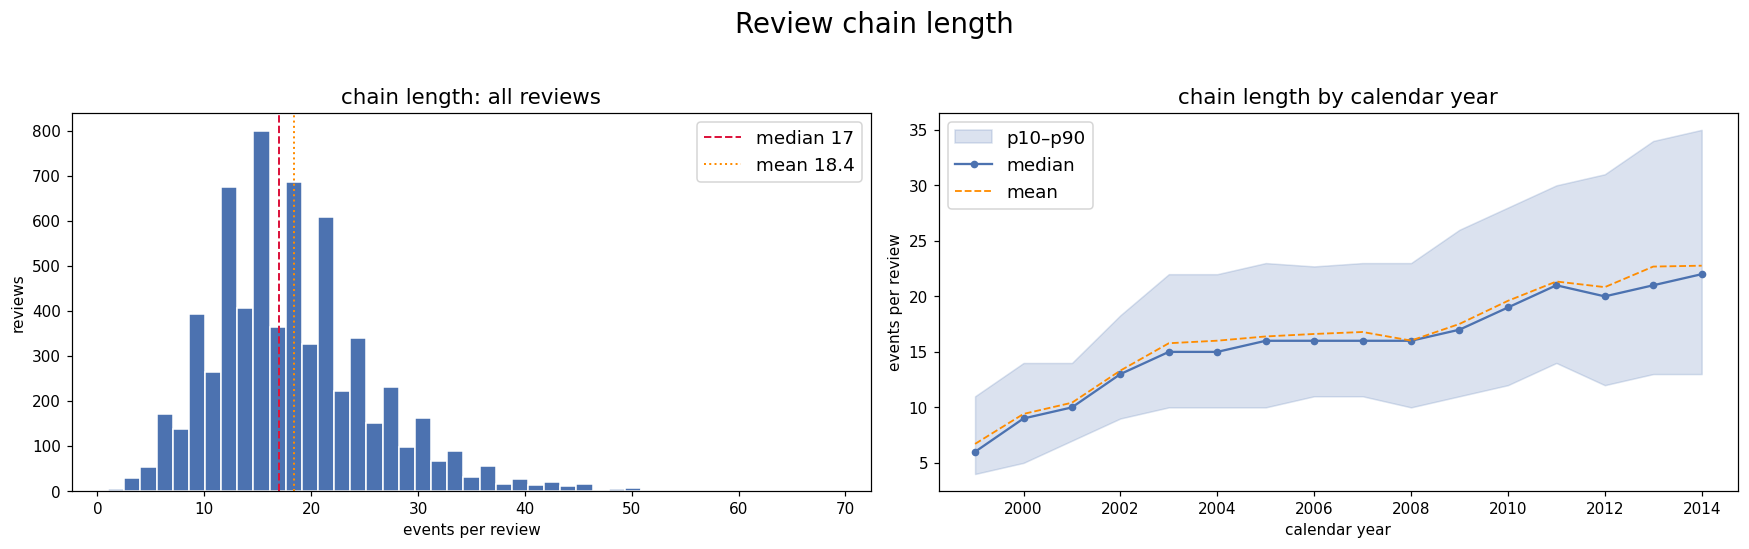

In [ ]:
# Cell 6: Chain length figure: distribution + drift over time

fig, ax = plt.subplots(1, 2, figsize=(16, 4.8))

# verall distribution
ax[0].hist(lengths, bins=45, color="#4C72B0", edgecolor="white")
ax[0].axvline(np.median(lengths), color="crimson", ls="--", lw=1.3,
              label=f"median {int(np.median(lengths))}")
ax[0].axvline(lengths.mean(), color="darkorange", ls=":", lw=1.3,
              label=f"mean {lengths.mean():.1f}")
ax[0].set_title("chain length: all reviews", fontsize=14)
ax[0].set_xlabel("events per review"); ax[0].set_ylabel("reviews"); ax[0].legend(fontsize=12)

# over calendar year: median line with the p10–p90 band
y = len_by_year.index
ax[1].fill_between(y, len_by_year["p10"], len_by_year["p90"], alpha=0.20, color="#4C72B0",
                   label="p10–p90")
ax[1].plot(y, len_by_year["median"], "-o", color="#4C72B0", ms=4, label="median")
ax[1].plot(y, len_by_year["mean"], "--", color="darkorange", lw=1.2, label="mean")
ax[1].set_title("chain length by calendar year", fontsize=14)
ax[1].set_xlabel("calendar year"); ax[1].set_ylabel("events per review"); ax[1].legend(fontsize=12)

fig.suptitle("Review chain length", y=1.03, fontsize=18)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_chain_length.png", bbox_inches="tight")
plt.show()

## 3. Per review

In [29]:
# Cell 13: Per-review composition tables (one wide CSV per alphabet)

review_tables = {}
for name, _ in ALPHABETS:
    d = DATA[name]
    counts, meta, vocab = d["counts"], d["meta"], d["vocab"]
    lengths = counts.sum(axis=1)
    props   = counts / lengths[:, None]
    order   = corpus_tables[name]["type"].tolist()          # columns by corpus rank

    tbl = meta[["review_id", "brand", "author", "year", "era", "season"]].copy()
    tbl["chain_len"]  = lengths
    tbl["n_distinct"] = (counts > 0).sum(axis=1)
    tbl["entropy_bits"] = [entropy_bits(props[i]) for i in range(len(props))]
    share_df = pd.DataFrame(props, columns=vocab)[order].add_prefix("share__")
    tbl = pd.concat([tbl.reset_index(drop=True), share_df.reset_index(drop=True)], axis=1)
    review_tables[name] = tbl
    tbl.round(4).to_csv(OUT_DIR / f"review_composition__{name}.csv", index=False)

    print(f"{name:11s} chain len median {np.median(lengths):.0f} "
          f"(p10 {np.percentile(lengths,10):.0f}, p90 {np.percentile(lengths,90):.0f})   "
          f"distinct types median {int(np.median(tbl['n_distinct']))}   "
          f"mix entropy mean {tbl['entropy_bits'].mean():.2f} bits")

Cluster_30  chain len median 17 (p10 10, p90 28)   distinct types median 9   mix entropy mean 2.73 bits
MR_4        chain len median 17 (p10 10, p90 28)   distinct types median 3   mix entropy mean 1.17 bits
Agency_6    chain len median 17 (p10 10, p90 28)   distinct types median 5   mix entropy mean 1.94 bits


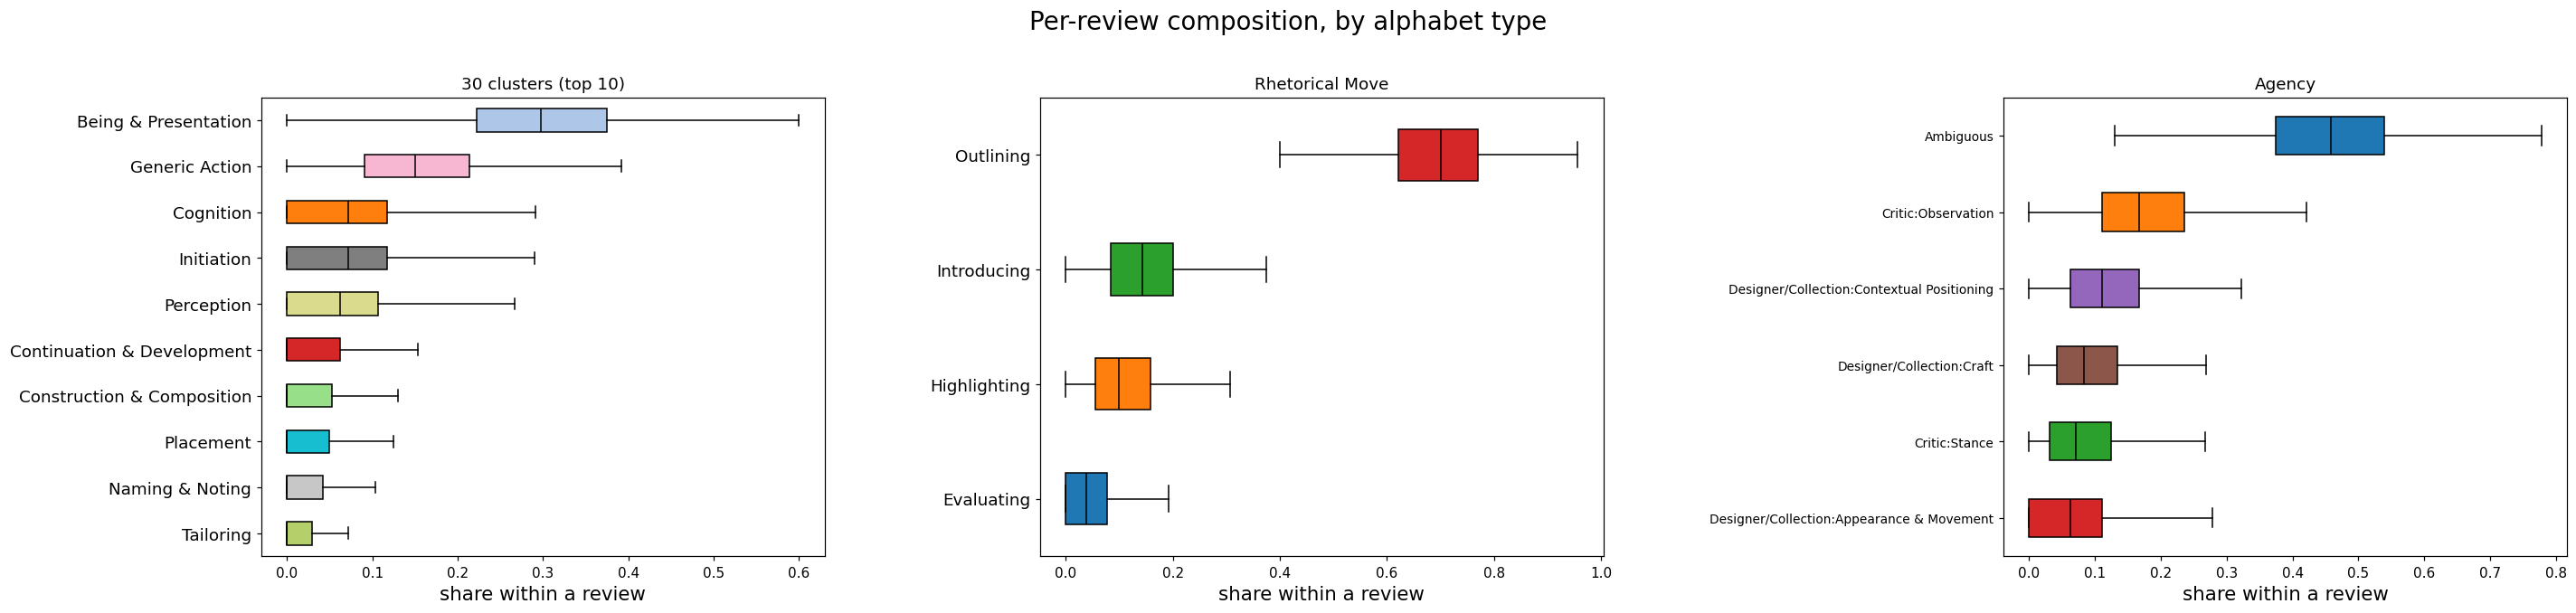

In [ ]:
# Cell 15: Per-review share by type

DISPLAY = {"Cluster_30": "30 clusters", "MR_4": "Rhetorical Move", "Agency_6": "Agency"}
TOP_N   = {"Cluster_30": 10}
YFONT   = {"Agency_6": 9}
YFONT_DEFAULT = 12

fig, axes = plt.subplots(1, 3, figsize=(26, 6))
for ax, (name, _) in zip(axes, ALPHABETS):
    tbl        = review_tables[name]
    order      = corpus_tables[name]["type"].tolist()
    if name in TOP_N:
        order = order[:TOP_N[name]]
    share_cols = [f"share__{t}" for t in order]

    data = [tbl[c].values for c in share_cols]
    bp = ax.boxplot(data, vert=False, showfliers=False, patch_artist=True,
                    medianprops=dict(color="k"))
    for patch, t in zip(bp["boxes"], order):
        patch.set_facecolor(COLORS[name][t])
    ax.set_yticklabels([t if len(t) <= 50 else t[:24] + "…" for t in order],
                       fontsize=YFONT.get(name, YFONT_DEFAULT))
    ax.invert_yaxis()
    title = DISPLAY[name] + (f" (top {TOP_N[name]})" if name in TOP_N else "")
    ax.set_title(title)
    ax.set_xlabel("share within a review", fontsize=14)

fig.suptitle("Per-review composition, by alphabet type", fontsize=18, y=1.02)
fig.tight_layout(w_pad=0.4)
p0, p1 = axes[0].get_position(), axes[1].get_position()
gap = p1.x0 - (p0.x0 + p0.width)
axes[1].set_position([p1.x0 - gap * 0.3, p1.y0, p1.width, p1.height])

fig.savefig(OUT_DIR / "fig_review_share_by_type.png", bbox_inches="tight")
plt.show()